In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("data_fileA_enhanced.csv")
df = pd.read_csv("data_fileA.csv")

In [3]:
df.columns

Index(['id', 'age', 'status', 'gender', 'diet', 'drinks', 'height', 'income',
       'last_online', 'location', 'offspring', 'sign', 'smokes', 'speaks',
       'age_group', 'messages_sent', 'profile_completion', 'account_age',
       'preferred_age_range', 'subscription_type',
       'self_rated_attractiveness'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         59946 non-null  int64  
 1   age                        59946 non-null  int64  
 2   status                     59946 non-null  object 
 3   gender                     59946 non-null  object 
 4   diet                       35551 non-null  object 
 5   drinks                     56961 non-null  object 
 6   height                     59943 non-null  float64
 7   income                     59946 non-null  int64  
 8   last_online                59946 non-null  object 
 9   location                   59946 non-null  object 
 10  offspring                  24385 non-null  object 
 11  sign                       48890 non-null  object 
 12  smokes                     54434 non-null  object 
 13  speaks                     59896 non-null  obj

In [4]:
df.head(2)

,id,age,status,gender,diet,drinks,height,income,last_online,location,...,sign,smokes,speaks,age_group,messages_sent,profile_completion,account_age,preferred_age_range,subscription_type,self_rated_attractiveness
0,618751,22,single,m,strictly anything,socially,75.0,-1,28/06/2012,"south san francisco, california",...,gemini,sometimes,english,18-24,102,59,3,18-27,Free,9
1,510466,35,single,m,mostly other,often,70.0,80000,29/06/2012,"oakland, california",...,cancer,no,"english (fluently), spanish (poorly), french (...",35-44,435,77,1,30-40,Free,5


# Q1

## <div dir='rtl'> <span style="color: #5A5A5A"> מצאו את המשכורת (income) החציונית של הגברים השייכים לשני המזלות (sign) הפופולאריים ביותר, ושדיווחו על משכורת.
<div dir='rtl'> 
הבהרות:
"דיווחו על משכורת" - יש אנשים שלא דיווחו על המשכורת שלהם. אין לקחת אותם בחשבון בעת החישוב. 
<div dir='rtl'> 
 דוגמה למי שמתקשה בהבנת השאלה: אם שני המזלות הנפוצים ביותר בדאטה הם מזל סרטן ומזל מאזניים, אז יש למצוא את המשכורת החציונית של הגברים השייכים למזלות סרטן ומאזניים. סוג המזל נמצא בעמודה sign.
<div dir='rtl'>     
בפלט יש להציג ערך מספרי אחד בלבד. תשובות שיציגו טבלה כלשהי יפסלו. 
</span>

In [9]:
zodiac = {
    "aries","taurus","gemini","cancer","leo","virgo",
    "libra","scorpio","sagittarius","capricorn","aquarius","pisces"
}

In [7]:
df["sign"].value_counts()

sign
gemini and it’s fun to think about         1782
scorpio and it’s fun to think about        1772
leo and it’s fun to think about            1692
libra and it’s fun to think about          1649
taurus and it’s fun to think about         1640
cancer and it’s fun to think about         1597
pisces and it’s fun to think about         1592
sagittarius and it’s fun to think about    1583
virgo and it’s fun to think about          1574
aries and it’s fun to think about          1573
aquarius and it’s fun to think about       1503
virgo but it doesn’t matter                1497
leo but it doesn’t matter                  1457
cancer but it doesn’t matter               1454
gemini but it doesn’t matter               1453
taurus but it doesn’t matter               1450
aquarius but it doesn’t matter             1408
libra but it doesn’t matter                1408
capricorn and it’s fun to think about      1376
sagittarius but it doesn’t matter          1375
aries but it doesn’t matter        

In [17]:
df["sign_clean"] = df["sign"].str.lower().str.strip().str.split().str[0]


In [13]:
df["sign_clean"].value_counts()

sign_clean
leo            4374
gemini         4310
libra          4207
cancer         4206
virgo          4141
taurus         4140
scorpio        4134
aries          3989
pisces         3946
sagittarius    3942
aquarius       3928
capricorn      3573
Name: count, dtype: int64

In [14]:
sign1 = df["sign_clean"].value_counts().index[0]
sign2 = df["sign_clean"].value_counts().index[1]
median_income = df[((df.sign == sign1) | (df.sign == sign2)) & (df.gender == "m") & (df.income > 0)]["income"].median()
median_income

np.float64(60000.0)

# Q2

## <div dir='rtl'> <span style="color: #5A5A5A">   מצאו את אחוז האנשים בגילאי 20-30 ששלחו מעל 200 הודעות (messages_sent). <div dir='rtl'> <span style="color: #5A5A5A">  
<div dir='rtl'> הבהרות:
אנשים מעל גיל 20 ומתחת לגיל 30. 

In [21]:
x = df[(df['age'] > 20 ) & (df['age'] <30) & (df['messages_sent'] > 200)].shape[0]
x

18539

In [22]:
y = df.shape[0]
y

59946

In [23]:
percentage = x/y * 100
percentage

30.92616688352851

# Q3


<div dir="rtl" style="text-align: right;">
    
### מצאו את שלושת ההעדפות התזונתיות (**diet**) מהן נשלחו הכי הרבה הודעות (**messages_sent**).  
### הציגו איור המראה את כמות ההודעות שנשלחו עבור כל אחת מהעדפות אלו, תוך הבחנה בין סוגי המנויים (**subscription_type**) של המשתמשים.
</div>

In [25]:
top_p = df.groupby(["diet"])[['messages_sent']].count().reset_index().sort_values(by="messages_sent", ascending=False).head(3)
top_p

,diet,messages_sent
3,mostly anything,16585
0,anything,6183
10,strictly anything,5113


In [26]:
p1, p2, p3 = top_p.iloc[0, 0], top_p.iloc[1, 0], top_p.iloc[2, 0]
print(p1)
print(p2)
print(p3)

mostly anything
anything
strictly anything


### count

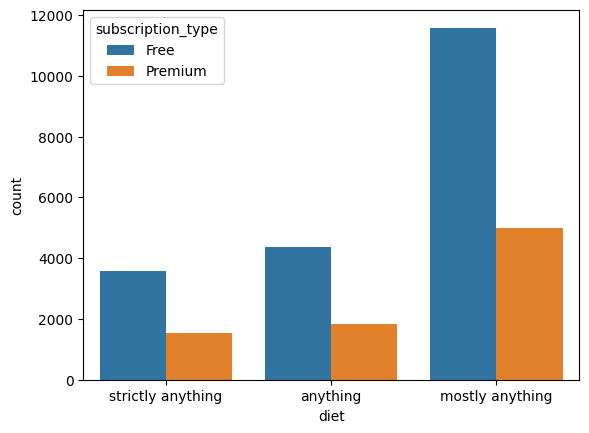

In [33]:
sns.countplot(data=df2 ,x='diet', hue='subscription_type');

### histplot

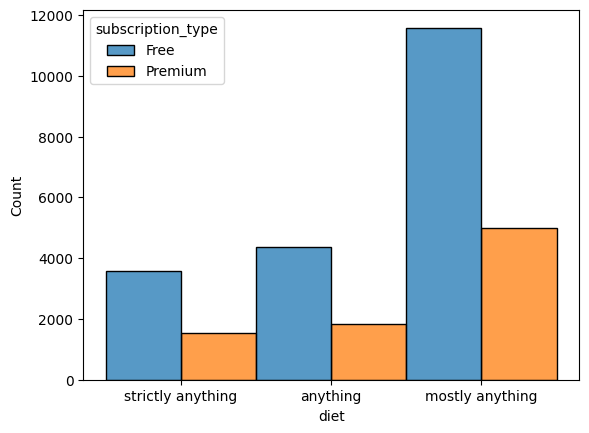

In [28]:
df2 = df[(df.diet == p1) | (df.diet == p2) | (df.diet == p3)]
sns.histplot(data=df2 ,x='diet', stat='count', hue='subscription_type', multiple = 'dodge', discrete= True)
plt.show()

### best ANS (can also do sum)

In [35]:
filtered_df = df[df["diet"].isin([p1, p2, p3])]


<Axes: xlabel='diet', ylabel='messages_sent'>

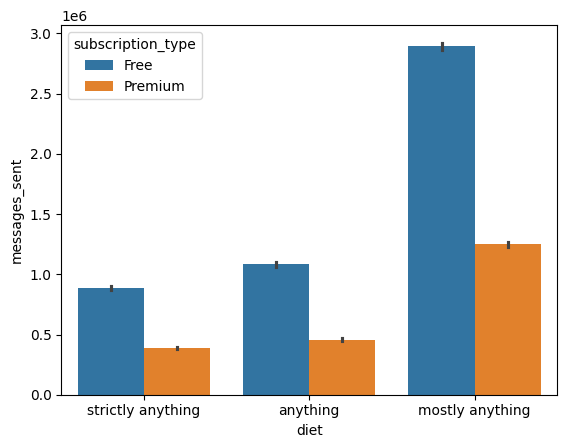

In [40]:
sns.barplot(filtered_df , x ='diet',y = 'messages_sent', hue = 'subscription_type',estimator = sum)
#sns.barplot(filtered_df , x ='diet',y = 'messages_sent', hue = 'subscription_type',estimator=lambda x: len(x)) # like countplot


# Q4

<div dir="rtl" style="text-align: right;">

### בעמודה (speaks) מופיעה רשימת השפות שכל משתמש מדבר, כאשר השפות מופרדות בפסיקים (`,`).  
    
<div dir="rtl" style="text-align: right;">

### פצלו את העמודה כך שכל שפה תקבל עמודה משלה, ולאחר מכן המיסו (melt) את הנתונים כך שכל שפה תופיע בשורה נפרדת.  
### מצאו את חמש השפות הנפוצות ביותר והציגו את שכיחותן באמצעות תרשים
### countplot.



## Option 1

In [49]:
langs = df["speaks"].str.split(",", expand=True)

In [48]:
df_test = df

In [61]:
ex_df = pd.concat([df_test,langs] ,axis=1)

In [66]:
ex_df.columns

Index([                       'id',                       'age',
                          'status',                    'gender',
                            'diet',                    'drinks',
                          'height',                    'income',
                     'last_online',                  'location',
                       'offspring',                      'sign',
                          'smokes',                    'speaks',
                       'age_group',             'messages_sent',
              'profile_completion',               'account_age',
             'preferred_age_range',         'subscription_type',
       'self_rated_attractiveness',                'sign_clean',
                                 0,                           1,
                                 2,                           3,
                                 4],
      dtype='object')

## And so on...

## Option 2

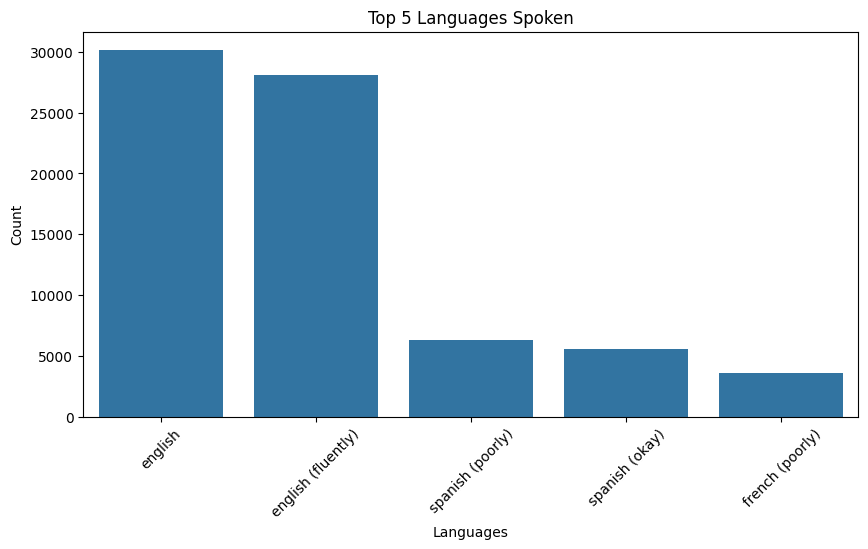

In [65]:
max_comma = int(df.speaks.str.count(',').max())  # Ensure it's an integer
list_s = df["speaks"].str.split(",", n=max_comma, expand=True)

for i in range(max_comma + 1):
    df[f"lang{i+1}"] = list_s[i]

ids = ['id']
values = ['lang1','lang2', 'lang3', 'lang4','lang5']
melted_df = pd.melt(df, id_vars= ids, value_vars= values)
melted_df = melted_df.rename(columns={'variable':'lang','value':'language'})

top_languages = melted_df["language"].value_counts().head(5).index

plt.figure(figsize=(10, 5))
sns.countplot(data=melted_df[melted_df["language"].isin(top_languages)], x="language", order=top_languages)
plt.xticks(rotation=45)
plt.xlabel("Languages")
plt.ylabel("Count")
plt.title("Top 5 Languages Spoken")
plt.show()



# Q5

<div dir="rtl" style="text-align: right;">
    
### השתמשו ב FacetGrid  כדי להציג כמה איורים. 
### כל איור יציג הרגלי אכילה (diet) אחרים. בכל איור הציגו את התפלגות ה self rated atractiveness  באחוזים. 
### על כל איור להיות בצבע אחר. 
### הערה: אם אינכם מציליחים לבצע FacetGrid, פתרו את השאלה באופן אחר, כדי שלא ירדו לכם כל הנקודות. 


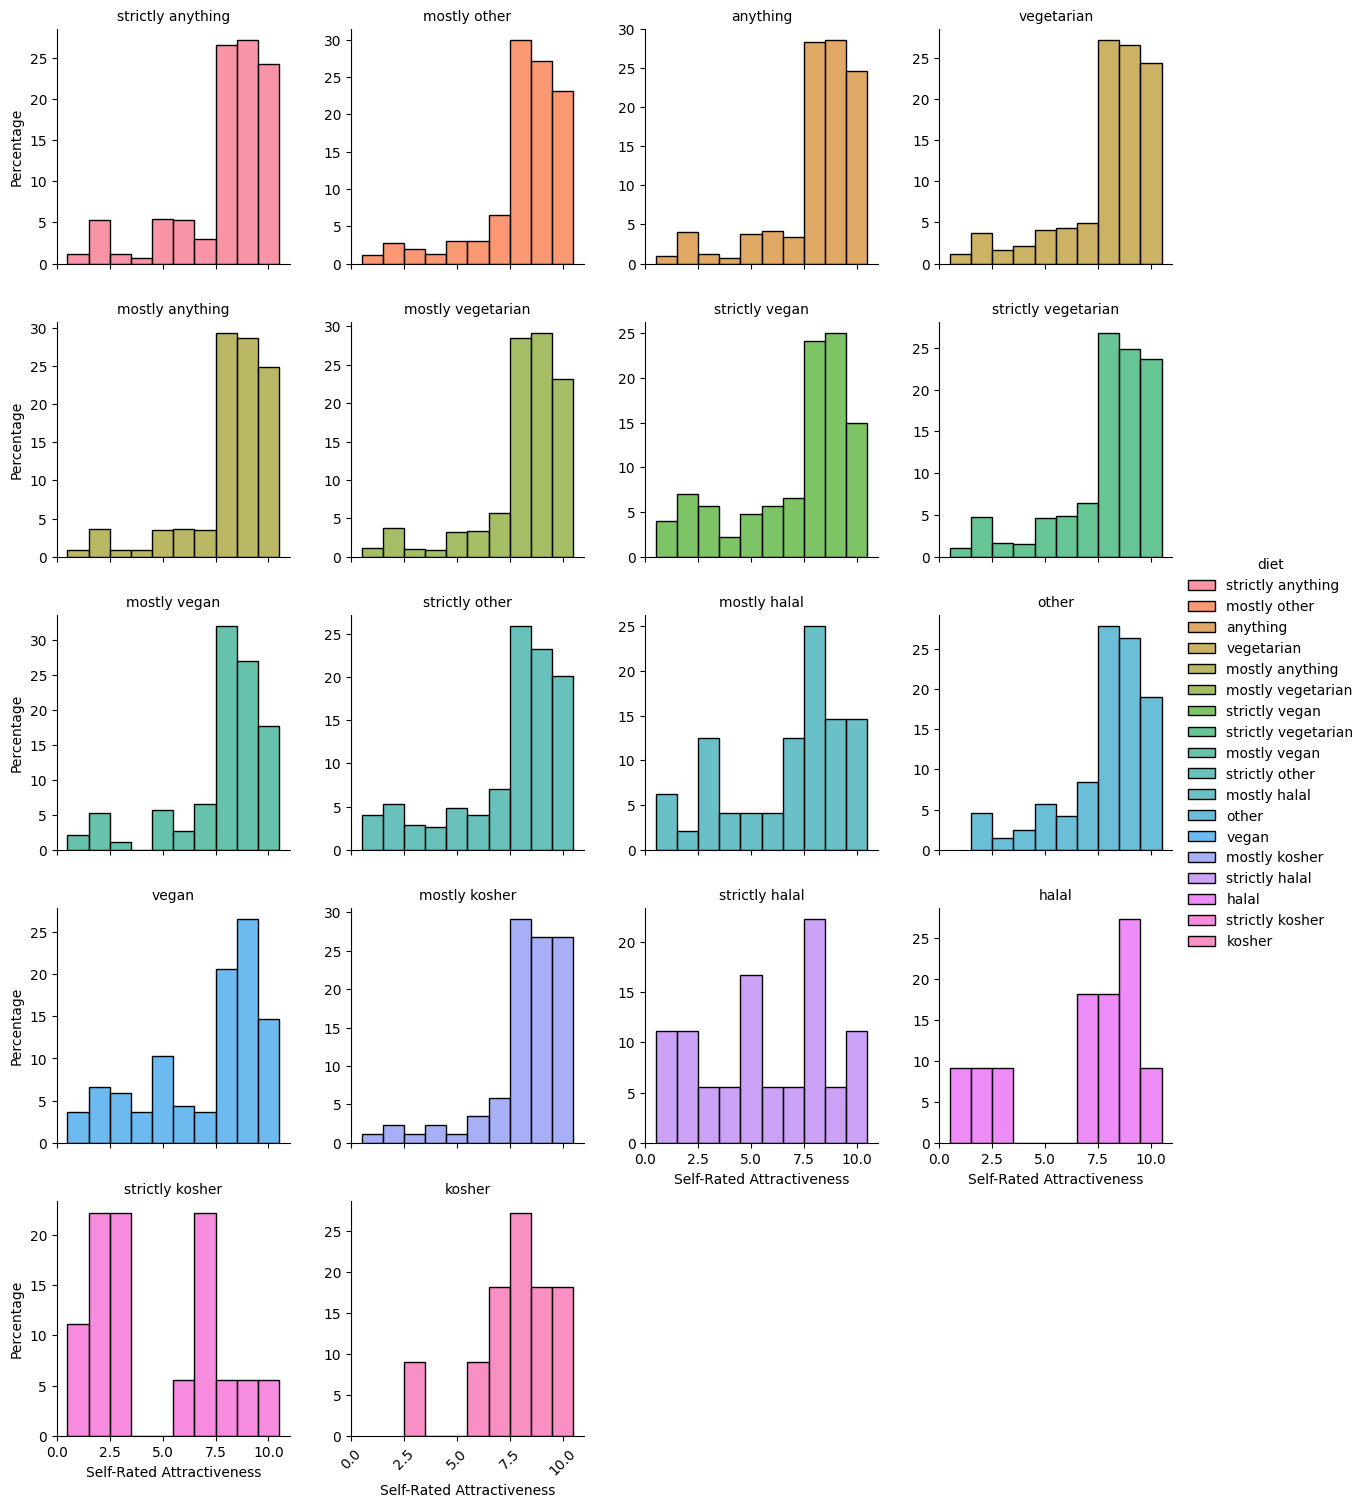

In [18]:
g = sns.FacetGrid(df, col="diet", col_wrap=4, sharex=True, sharey=False, hue="diet")

g.map_dataframe(sns.histplot, x="self_rated_attractiveness", stat="percent", discrete=True)

g.set_axis_labels("Self-Rated Attractiveness", "Percentage")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.xticks(rotation=45)
plt.show()



# Q6

<div dir="rtl" style="text-align: right;">

### הציגו באיור את חציון הפרופילים שהושלמו(profile_completion) 
### עבור כל סוג מנוי (subscription_type) 
### בכל אחד מחודשי השנה (מתוך last_online)
### הבהרות: כן, יש לטפל תחילה בעמודה last_online כדי שתתאים. 
### ניתן להוסיף עמודות חדשות.
### אין צורך לטפל בעמודת profile_competion


C:\Users\lihin\AppData\Local\Temp\ipykernel_13540\3569780409.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['last_online_date'] = pd.to_datetime(df['last_online'])


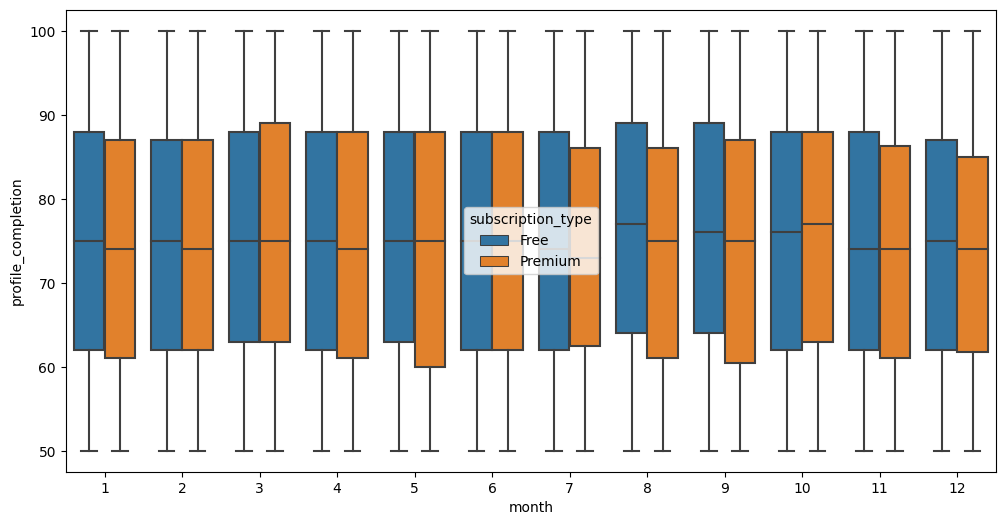

In [19]:

df['last_online_date'] = pd.to_datetime(df['last_online'])
df["month"] = df["last_online_date"].dt.month  # Extract month



plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="month", y="profile_completion", hue="subscription_type")


plt.show()




# Q7

<div dir="rtl" style="text-align: right;">
    
### צרו מפת חום (heatmap) המציגה את הקורלציות בין ['subscription_type',  'drinks', 'messages_sent' ,'self_rated_attractiveness']
### מצאו את הקשר החזק ביותר והציגו אותו באמצעות איור. שימו את שני האיורים אחד ליד השני (האיור של מפת החום והאיור עם הקורלציה)


In [93]:
categorical_features = ['subscription_type',  'drinks']
numeric_features = ['messages_sent' ,"self_rated_attractiveness"]
all_features = numeric_features + categorical_features

df_dummies = pd.get_dummies(df[all_features])
df_dummies.columns

Index(['messages_sent', 'self_rated_attractiveness', 'subscription_type_Free',
       'subscription_type_Premium', 'drinks_desperately', 'drinks_not at all',
       'drinks_often', 'drinks_rarely', 'drinks_socially',
       'drinks_very often'],
      dtype='object')

In [94]:
# Compute correlation matrix
correlation_matrix = df_dummies.corr()
correlation_matrix = df_dummies.corr(method= "spearman").round(2)

<Axes: xlabel='drinks_socially', ylabel='self_rated_attractiveness'>

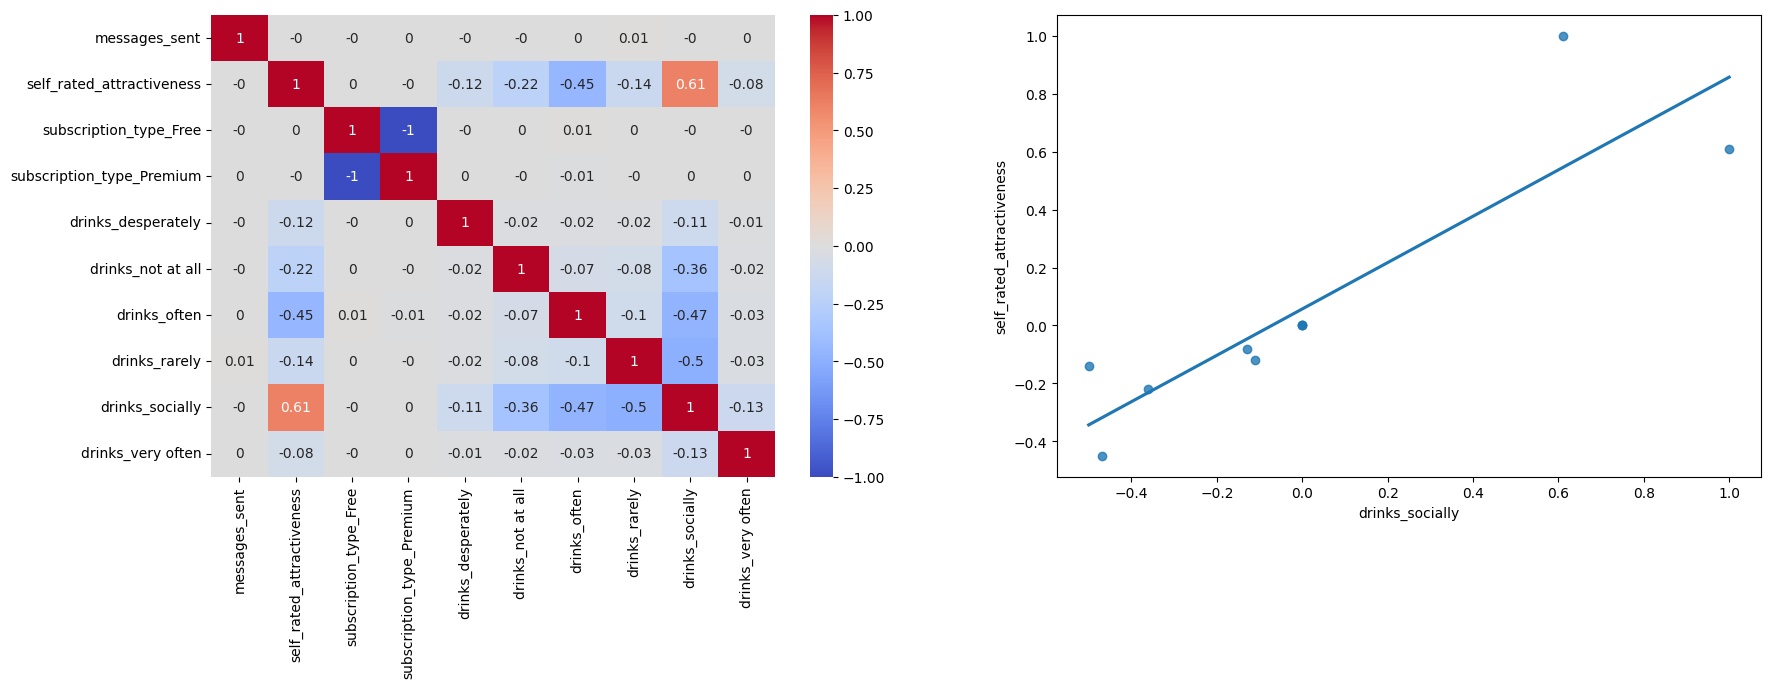

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[0])
sns.regplot(y='self_rated_attractiveness', x='drinks_socially', data=correlation_matrix, ci=None,ax = axes[1])


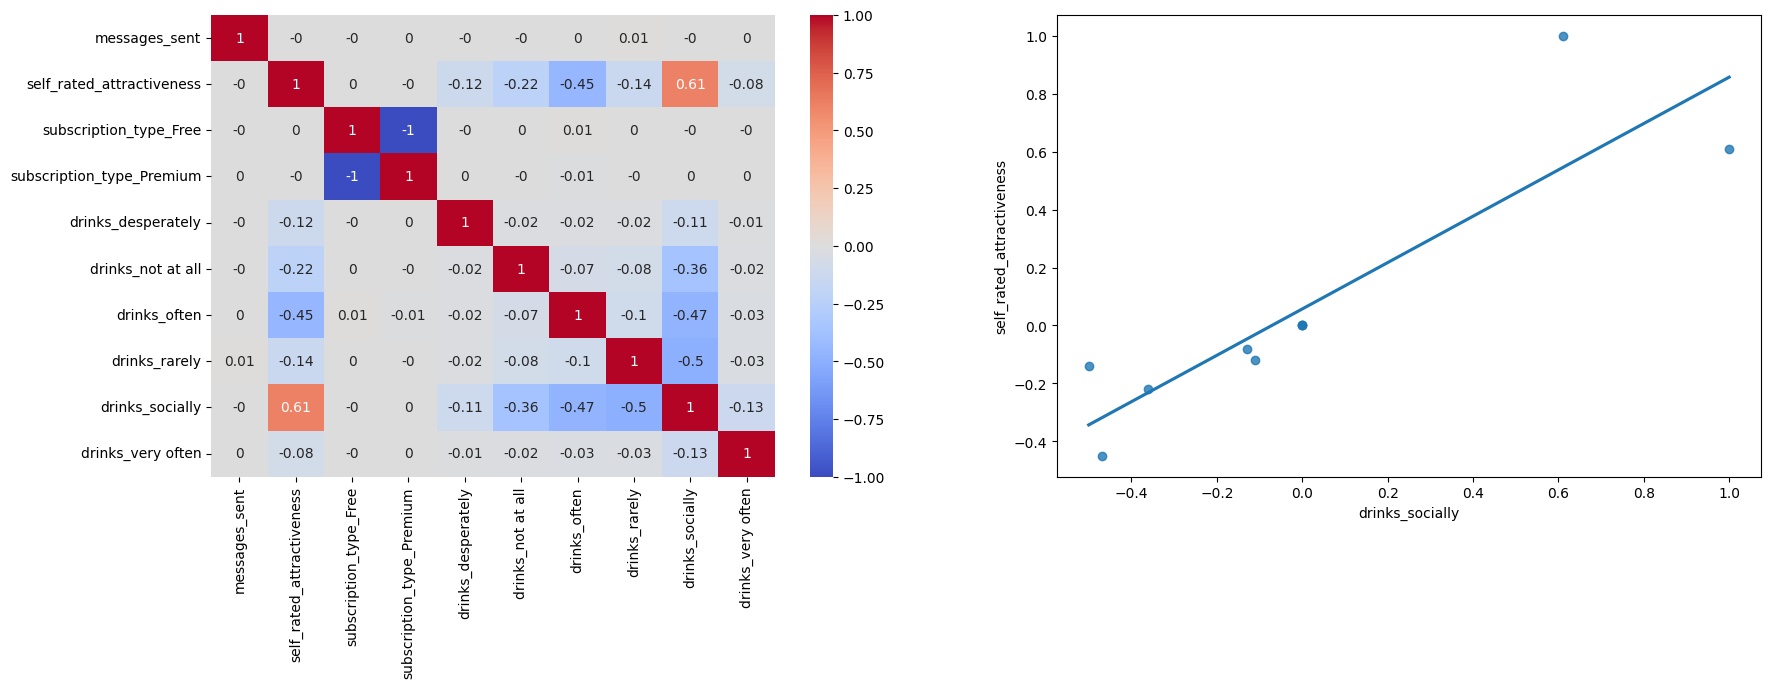

In [97]:
fig, ax = plt.subplots(1,2, figsize = (20, 6))


sns.heatmap(data=correlation_matrix, cmap='coolwarm', annot = True,  ax=ax[0])
#sns.scatterplot(data = df_dummies , y = 'self_rated_attractiveness', x ='drinks_socially',  ax=ax[1])
sns.regplot(y='self_rated_attractiveness', x='drinks_socially', data=correlation_matrix, ci=None,ax = ax[1])
plt.show()

-----

# Q8

<div dir="rtl" style="text-align: right;">

### מצאו את ארבעת הקטגוריות הנפוצות ביותר בעמודה offspring 
### הציגו איור המשווה בין אחוז הגברים והנשים עבור כל אחת מהקטגוריות. 


In [98]:
top_offspring = df["offspring"].value_counts().index[:4]

In [99]:
df_top = df[df["offspring"].isin(top_offspring)]

# another option:
#df_top = df[
#    (df["offspring"] == top_offspring[0]) |
#    (df["offspring"] == top_offspring[1]) |
#    (df["offspring"] == top_offspring[2]) |
#    (df["offspring"] == top_offspring[3])
#]

## Option 1

In [134]:
a = df_top.groupby("gender")["offspring"].value_counts().reset_index()

In [135]:
a

,gender,offspring,count
0,f,doesn't have kids,3125
1,f,"doesn't have kids, but wants them",1840
2,f,"doesn't have kids, but might want them",1506
3,f,doesn't want kids,1177
4,m,doesn't have kids,4435
5,m,"doesn't have kids, but might want them",2369
6,m,doesn't want kids,1750
7,m,"doesn't have kids, but wants them",1725


In [136]:
totals = a.groupby("gender")["count"].sum()

In [137]:
a["percentage"] = a["count"] / a["gender"].map(totals) * 100


In [138]:
a

,gender,offspring,count,percentage
0,f,doesn't have kids,3125,40.860356
1,f,"doesn't have kids, but wants them",1840,24.058577
2,f,"doesn't have kids, but might want them",1506,19.691423
3,f,doesn't want kids,1177,15.389644
4,m,doesn't have kids,4435,43.146220
5,m,"doesn't have kids, but might want them",2369,23.046989
6,m,doesn't want kids,1750,17.025002
7,m,"doesn't have kids, but wants them",1725,16.781788


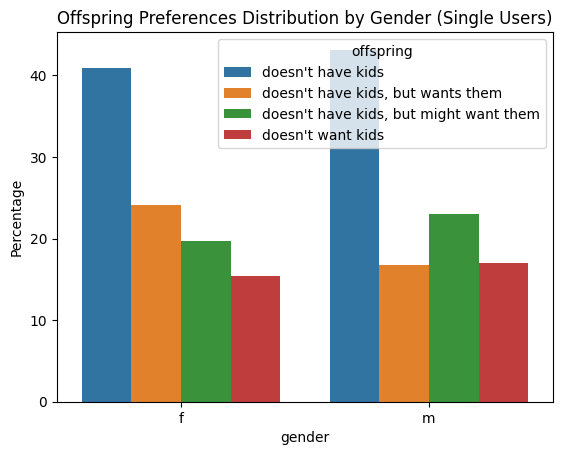

In [139]:
sns.barplot(data= a, x="gender", y="percentage", hue="offspring")
plt.ylabel("Percentage")
plt.title("Offspring Preferences Distribution by Gender (Single Users)")
plt.show()

## Option 2

In [26]:
df_percentage = df_top.groupby("gender")["offspring"].value_counts(normalize=True).mul(100).reset_index(name="percentage")
df_percentage 

,gender,offspring,percentage
0,f,doesn't have kids,40.860356
1,f,"doesn't have kids, but wants them",24.058577
2,f,"doesn't have kids, but might want them",19.691423
3,f,doesn't want kids,15.389644
4,m,doesn't have kids,43.146220
5,m,"doesn't have kids, but might want them",23.046989
6,m,doesn't want kids,17.025002
7,m,"doesn't have kids, but wants them",16.781788


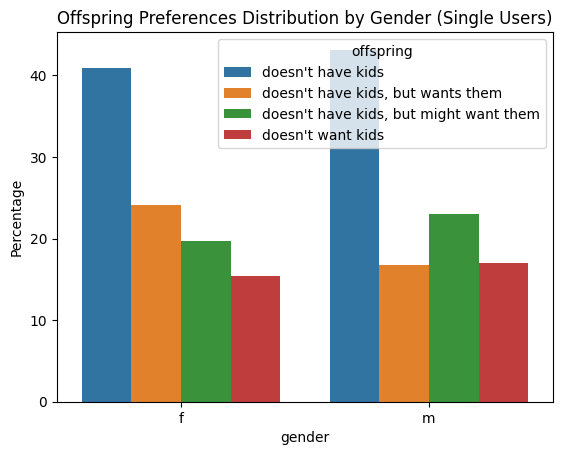

In [27]:
sns.barplot(data=df_percentage, x="gender", y="percentage", hue="offspring")
plt.ylabel("Percentage")
plt.title("Offspring Preferences Distribution by Gender (Single Users)")
plt.show()
